# Association Testing

## Objective
The goal of this analysis is to investigate the relationship between Food Microbiome Exposure (FME) and gut microbiome characteristics.

Specifically, we examine whether FME is associated with:

- Alpha diversity (Shannon diversity)
- Microbiome stability
- Community composition metrics

This analysis is based on the dataset generated in the FME analysis stage.

In [40]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings
pd.set_option("display.max_columns", None)

# Model imports
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

#Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Regression imports
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import clone

from config import DATA_DIR

In [41]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


## Dataset Overview

In this section, we load and inspect the statistical dataset created in the FME analysis step.

The goal is to understand the structure of the dataset, including the number of samples, available variables, data types, and missing values before performing association testing.

In [42]:
# Load the statistical dataset created in the FME analysis step

df = pd.read_csv(DATA_DIR / "fme_statistical_dataset.csv")

df.head()

,fecal_sample_id,participant_id,study_day,Gender,Age,BMI,Weight,Supplement,Medications,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
0,MCT.f.0002,MCTs01,2,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),67.1961,2.8627,0.0492,3.0662,15,1970.0436,109.6198,53.6153,242.9190,14.4194,74.2081,4300.6165,4.1560,0.6460,1.1535,0.0000,3.9690,0.9718
1,MCT.f.0003,MCTs01,3,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),81.2412,3.5228,0.0492,3.0662,15,1714.8953,89.9930,50.5614,234.2251,25.9961,67.4747,4225.8133,2.9797,0.6460,1.2076,0.0000,0.0000,2.9318
2,MCT.f.0004,MCTs01,4,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),126.7711,3.0312,0.0492,3.0662,15,2487.2326,94.6120,92.0216,257.5390,26.1784,83.9603,5329.8821,3.6345,0.0000,1.4826,0.0000,0.0000,0.9718
3,MCT.f.0005,MCTs01,5,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),31.4846,2.9738,0.0492,3.0662,15,2260.2112,110.2684,95.5703,165.6081,13.0114,64.9220,3527.5014,3.3797,0.0000,1.0590,1.8144,0.0000,0.9718
4,MCT.f.0006,MCTs01,6,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),61.2266,3.0811,0.0492,3.0662,15,2951.0820,161.8178,108.3985,332.6372,21.5291,119.8657,5428.5730,1.5022,0.0000,0.0000,6.2960,0.0000,0.4698


In [43]:
# Dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (475, 27)

Columns:
['fecal_sample_id', 'participant_id', 'study_day', 'Gender', 'Age', 'BMI', 'Weight', 'Supplement', 'Medications', 'fme_score_daily', 'shannon_diversity', 'participant_shannon_cv', 'participant_shannon_mean', 'participant_n_samples', 'KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE', 'SUGR', 'SODI', 'D_TOTAL', 'D_YOGURT', 'D_CHEESE', 'PF_MEAT', 'PF_SEAFD_HI', 'G_WHOLE']


In [44]:
# Summary statistics

df.describe()

,study_day,Age,BMI,Weight,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
count,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000
mean,8.9516,31.1522,23.1747,69.0691,73.3252,2.8646,0.0626,2.8646,14.6042,2110.5628,89.1449,91.5124,229.0660,22.3371,85.2199,3491.5642,1.9216,0.1109,0.9935,1.1907,0.3251,1.2634
std,4.9397,10.1565,3.2921,14.6469,58.3071,0.4132,0.0377,0.3684,2.4294,735.4510,37.3946,40.2129,84.4877,11.6002,43.4681,1629.7738,1.5415,0.2717,1.3396,2.3080,1.5762,1.6287
min,1.0000,19.7000,17.0000,48.5000,0.0000,1.5717,0.0202,1.9446,6.0000,722.5525,15.7029,20.4671,45.0466,3.6180,11.3055,550.8530,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,5.0000,23.9000,21.1000,59.1000,29.3222,2.6108,0.0365,2.5302,14.0000,1599.1798,62.9492,60.9105,176.9681,14.8500,53.0450,2317.4232,0.6647,0.0000,0.0000,0.0000,0.0000,0.0000
50%,9.0000,28.5000,22.9000,66.9000,61.7775,2.9644,0.0489,3.0128,15.0000,2028.1680,85.4969,85.5937,217.0000,19.6938,81.2160,3314.3400,1.6505,0.0000,0.5724,0.0000,0.0000,0.6518
75%,13.0000,37.0000,25.9000,82.9000,104.2697,3.1430,0.0799,3.1301,16.0000,2494.0985,106.2595,116.1724,271.9399,26.7118,110.0421,4310.1226,2.7543,0.0000,1.4549,1.5742,0.0000,2.0936
max,17.0000,61.6000,31.6000,104.8000,331.2240,3.7310,0.1799,3.4834,17.0000,5085.9774,256.4990,242.7618,582.0150,67.5019,261.8574,13884.2473,9.3234,1.6650,9.0474,17.5770,20.7692,9.9346


In [45]:
print(df.isnull().sum())

fecal_sample_id               0
participant_id                0
study_day                     0
Gender                        0
Age                           0
BMI                           0
Weight                        0
Supplement                    0
Medications                 255
fme_score_daily               0
shannon_diversity             0
participant_shannon_cv        0
participant_shannon_mean      0
participant_n_samples         0
KCAL                          0
PROT                          0
TFAT                          0
CARB                          0
FIBE                          0
SUGR                          0
SODI                          0
D_TOTAL                       0
D_YOGURT                      0
D_CHEESE                      0
PF_MEAT                       0
PF_SEAFD_HI                   0
G_WHOLE                       0
dtype: int64


## Correlation Analysis

In this section, we investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity metrics.

We begin by examining the correlation between the daily FME score and Shannon diversity, which is a commonly used measure of microbiome diversity.

In [46]:
# Correlation between FME and Shannon Diversity

correlation, p_value = pearsonr(
    df["fme_score_daily"],
    df["shannon_diversity"]
)

print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation: -0.0406
P-value: 0.3776


### Visualization of FME and Shannon Diversity

The following scatter plot illustrates the relationship between daily Food Microbiome Exposure (FME) scores and Shannon diversity values across all samples.

A regression line is added to help visualize the overall trend.

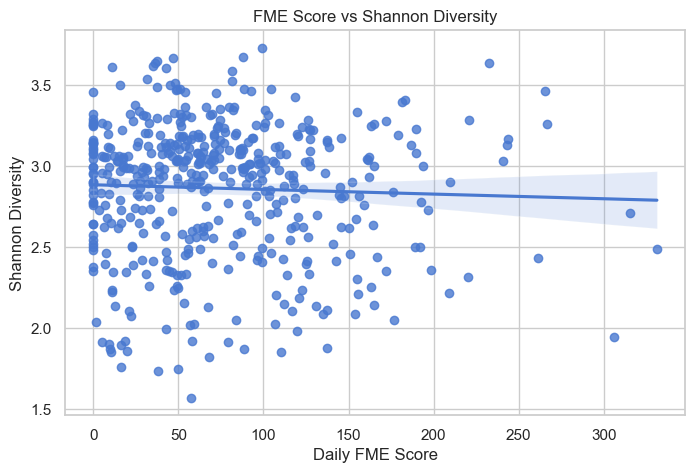

In [47]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="fme_score_daily",
    y="shannon_diversity"
)

plt.title("FME Score vs Shannon Diversity")
plt.xlabel("Daily FME Score")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The relationship between FME score and Shannon diversity appears to be weak.

Although FME values vary considerably across samples, Shannon diversity remains relatively stable.

The nearly flat regression line suggests little to no linear association between the two variables.

## Correlation Matrix

To better understand the relationships between microbiome-related variables, we compute a correlation matrix for the main numerical variables used in this analysis.

In [48]:
correlation_columns = [
    "fme_score_daily",
    "shannon_diversity",
    "participant_shannon_cv",
    "participant_shannon_mean"
]

corr_matrix = df[correlation_columns].corr()

corr_matrix

,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean
fme_score_daily,1.0000,-0.0406,-0.0771,-0.0153
shannon_diversity,-0.0406,1.0000,-0.4929,0.8917
participant_shannon_cv,-0.0771,-0.4929,1.0000,-0.5527
participant_shannon_mean,-0.0153,0.8917,-0.5527,1.0000


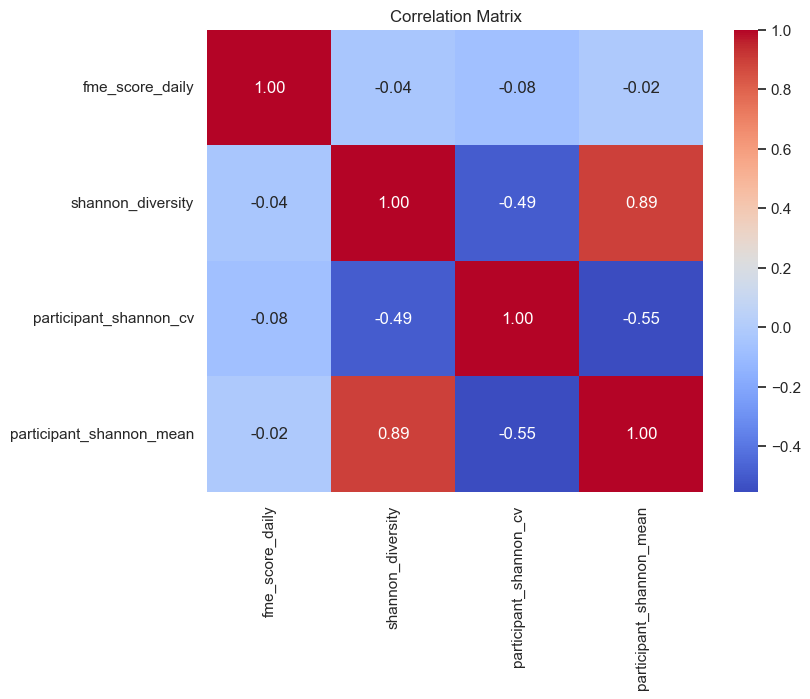

In [49]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Insight

FME score has very weak correlations with all diversity metrics.

Shannon diversity is strongly correlated with participant mean Shannon diversity.

## Comparison Between Low and High FME Groups

To further investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity, samples were divided into two groups based on the median FME score.

Shannon diversity distributions were then compared between the groups.

In [50]:
# Create FME groups based on median value

median_fme = df["fme_score_daily"].median()

df["fme_group"] = np.where(
    df["fme_score_daily"] >= median_fme,
    "High FME",
    "Low FME"
)

df["fme_group"].value_counts()

fme_group
High FME    238
Low FME     237
Name: count, dtype: int64

### Shannon Diversity by FME Group

The following boxplot compares Shannon diversity values between samples with low and high Food Microbiome Exposure.

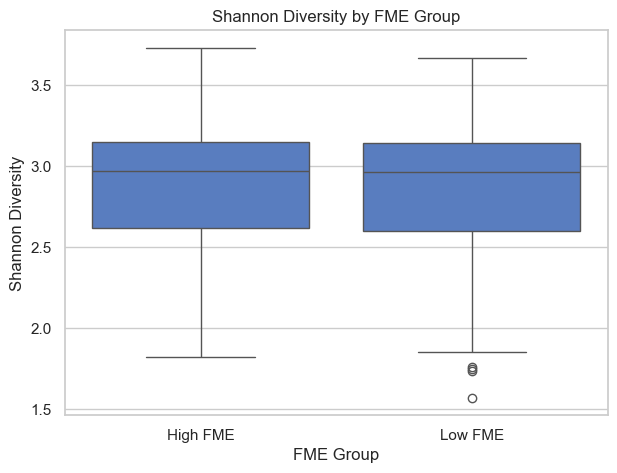

In [51]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="fme_group",
    y="shannon_diversity"
)

plt.title("Shannon Diversity by FME Group")
plt.xlabel("FME Group")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The distributions of Shannon diversity are similar in both FME groups.

No clear difference in diversity is observed between low and high FME exposure levels.

### Statistical Test

A Mann–Whitney U test was performed to evaluate whether Shannon diversity differs significantly between the two FME groups.

In [52]:
high_fme = df[df["fme_group"] == "High FME"]["shannon_diversity"]
low_fme = df[df["fme_group"] == "Low FME"]["shannon_diversity"]

stat, p_value = mannwhitneyu(high_fme, low_fme)

print("Mann-Whitney U Statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U Statistic: 28228.0
P-value: 0.9869319368980619


### Insight

No significant difference was found between the low and high FME groups (p = 0.987).

This suggests that FME levels are not associated with differences in Shannon diversity in this dataset.

## Adjusted Regression Analysis

To account for potential dietary confounders, an additional regression model was fitted including nutrient intake variables.

This allows evaluation of the association between FME and Shannon diversity while controlling for dietary factors.

In [53]:
model_adj = smf.ols(
    "shannon_diversity ~ fme_score_daily + KCAL + PROT + TFAT + CARB + FIBE",
    data=df
).fit()

print(model_adj.summary())

                            OLS Regression Results                            
Dep. Variable:      shannon_diversity   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.152
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0465
Time:                        23:09:08   Log-Likelihood:                -247.17
No. Observations:                 475   AIC:                             508.3
Df Residuals:                     468   BIC:                             537.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.7853      0.061     

### Insight

After adjusting for nutrient intake variables, FME score remained a non-significant predictor of Shannon diversity (p = 0.876).

This suggests that the observed lack of association is not explained by differences in dietary intake.

# Conclusions

Several statistical approaches were used to evaluate the relationship between Food Microbiome Exposure (FME) and gut microbiome diversity.

Main findings:

- The correlation between FME score and Shannon diversity was very weak.
- No significant differences were observed between low and high FME groups.
- Simple linear regression showed that FME score was not a significant predictor of Shannon diversity.
- After adjusting for dietary intake variables (KCAL, PROT, TFAT, CARB, and FIBE), FME score remained non-significant.
- Adjusting for nutrient intake did not change the overall findings.

Overall, no statistically significant association was found between FME levels and Shannon diversity in this dataset.

# Food Microbiome Exposure (FME) Analysis
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
1. **Data Transfer** — Load all preprocessed datasets from both sources
2. **Data Mapping** — Map dietary food items to cFMD food categories
3. **FME Quantification** — Calculate a daily Food Microbiome Exposure score per fecal sample
4. **Statistical Dataset** — Assemble one clean table ready for statistical modelling

### Key structural note
> The Johnson et al. 2019 study has **34 participants**, each contributing multiple fecal samples across up to 17 study days.
> All FME scores are computed at the **fecal sample level** (one score per sample = one dietary day per person).
> Participant-level summaries are derived by aggregating across samples — **not** by treating samples as independent observations.
> The unit of analysis for statistical models is the **fecal sample**, with participant included as a random effect.


---
## Section 1 – Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


Libraries loaded.


In [55]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


---
## Section 2 – Data Transfer: Load All Datasets

### Source 1 — Johnson et al. 2019 (gut microbiome + diet)
34 participants · up to 17 fecal samples each · 566 samples total

### Source 2 — Carlino et al. 2024 — cFMD (food microbiome)
3,393 food samples · 5,057 microbial taxa


In [56]:
# ── Source 1: Gut microbiome matrices (taxa × fecal samples) ───────────────────
gut_microbiome_abundance  = pd.read_csv(DATA_DIR / "microbiome_filtered.csv", index_col=0)

# ── Source 1: Fecal sample metadata ────────────────────────────────────────────
# index = fecal sample ID (MCT.f.XXXX)
# columns: UserName (= participant), StudyDayNo, Gender, Age, BMI, ...
fecal_sample_metadata     = pd.read_csv(DATA_DIR / "sample_meta.csv",         index_col=0)

# ── Source 1: Dietary consumption matrix (food items × fecal samples) ──────────
# rows = food items, columns = fecal sample IDs (MCT.f.XXXX)
# values = consumption amount of that food on that day
dietary_consumption_matrix= pd.read_csv(DATA_DIR / "diet_raw.csv")

# ── Source 1: Daily nutrition totals ───────────────────────────────────────────
# index = fecal sample ID
daily_nutrition_totals    = pd.read_csv(DATA_DIR / "nutrition_totals.csv",    index_col=0)

# ── Source 1: Additional dietary features ──────────────────────────────────────
daily_fiber_scores        = pd.read_csv(DATA_DIR / "diet_fiber.csv")
daily_decay_scores        = pd.read_csv(DATA_DIR / "diet_decay.csv")
participant_fiber_avg     = pd.read_csv(DATA_DIR / "fiber_avg.csv")

# ── Source 2: cFMD food microbiome abundance (food taxa × food samples) ─────────
# columns: 'StudyName__ShortSampleID' format
cfmd_food_abundance       = pd.read_csv(DATA_DIR / "combined_datasets.csv",   index_col=0, low_memory=False)
cfmd_food_abundance       = cfmd_food_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# ── Source 2: cFMD sample metadata ─────────────────────────────────────────────
# columns: sample_id, category, fermented/non-fermented, country, ...
cfmd_food_metadata        = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

# ── Verify participant count ────────────────────────────────────────────────────
n_participants = fecal_sample_metadata["UserName"].nunique()
n_fecal_samples= len(fecal_sample_metadata)

print(f"Participants          : {n_participants}  (expected: 34)")
print(f"Fecal samples total   : {n_fecal_samples}")
print(f"Avg samples/person    : {n_fecal_samples / n_participants:.1f}")
print()
print("Dataset sizes:")
for name, df in [
    ("gut_microbiome_abundance",   gut_microbiome_abundance),
    ("fecal_sample_metadata",      fecal_sample_metadata),
    ("dietary_consumption_matrix", dietary_consumption_matrix),
    ("daily_nutrition_totals",     daily_nutrition_totals),
    ("cfmd_food_abundance",        cfmd_food_abundance),
    ("cfmd_food_metadata",         cfmd_food_metadata),
]:
    print(f"  {name:<32} {str(df.shape)}")


Participants          : 34  (expected: 34)
Fecal samples total   : 566
Avg samples/person    : 16.6

Dataset sizes:
  gut_microbiome_abundance         (223, 483)
  fecal_sample_metadata            (566, 28)
  dietary_consumption_matrix       (1452, 568)
  daily_nutrition_totals           (580, 106)
  cfmd_food_abundance              (5057, 3393)
  cfmd_food_metadata               (3444, 32)


---
## Section 3 – Define the Analytical Sample Set

Only fecal samples that have **both** a gut microbiome measurement **and** a dietary record
form the analytical core. We identify these 475 samples here.


In [57]:
# ── Identify fecal sample IDs present in both gut microbiome and diet data ──────
FECAL_SAMPLE_PREFIX = "MCT.f."

gut_microbiome_sample_ids = set(gut_microbiome_abundance.columns)
diet_record_sample_ids    = set(
    c for c in dietary_consumption_matrix.columns
    if c.startswith(FECAL_SAMPLE_PREFIX)
)

# Core analytical set: samples with BOTH gut microbiome AND diet record
analytical_sample_ids = sorted(gut_microbiome_sample_ids & diet_record_sample_ids)

print(f"Gut microbiome samples         : {len(gut_microbiome_sample_ids)}")
print(f"Diet record samples            : {len(diet_record_sample_ids)}")
print(f"Analytical samples (gut∩diet)  : {len(analytical_sample_ids)}")
print()

# Participants represented in the analytical set
analytical_participants = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids), "UserName"]
    .nunique()
)
print(f"Participants represented       : {analytical_participants} / {n_participants}")

# Samples per participant in the analytical set
samples_per_participant = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids)]
    .groupby("UserName")
    .size()
    .rename("n_analytical_samples")
)
print(f"Avg analytical samples/person  : {samples_per_participant.mean():.1f}")
print(f"Min / Max                      : {samples_per_participant.min()} / {samples_per_participant.max()}")


Gut microbiome samples         : 483
Diet record samples            : 566
Analytical samples (gut∩diet)  : 475

Participants represented       : 34 / 34
Avg analytical samples/person  : 14.0
Min / Max                      : 6 / 17


---
## Section 4 – FME Weights from cFMD

**Goal:** Derive a microbial richness weight for each cFMD food category.

**Why richness, not total abundance?**
The `combined_datasets` matrix stores relative abundance — each sample sums to 100 regardless of food type.
Total abundance is therefore uninformative as a weight.
**Microbial richness** (= number of distinct taxa detected per food sample) reflects how microbiome-diverse each food category truly is.

**Weight formula:**
$$w_c = \frac{\text{mean\_richness}_c - \min}{\max - \min} \quad \in [0, 1]$$

Weights are derived directly from the **cFMD food abundance matrix** — not assumed or hand-coded.


In [58]:
# ── Step 1: Map cFMD column names → food category + fermentation status ─────────
# combined_datasets columns: 'StudyName__ShortSampleID'
# cfmd_food_metadata sample_id: 'ShortSampleID'

def extract_cfmd_short_id(column_name):
    """Strip the study name prefix from a combined_datasets column name."""
    return column_name.split("__")[-1] if "__" in column_name else column_name

# Remove the one duplicate sample_id (VB15-29) before indexing
cfmd_food_metadata_dedup = cfmd_food_metadata.drop_duplicates(
    subset="sample_id", keep="first"
)
print(f"cFMD metadata after dedup: {len(cfmd_food_metadata_dedup)} rows "
      f"(removed {len(cfmd_food_metadata) - len(cfmd_food_metadata_dedup)} duplicate)")

cfmd_id_to_meta = (
    cfmd_food_metadata_dedup
    .set_index("sample_id")[["category", "fermented/non-fermented"]]
    .to_dict(orient="index")
)

# Map each column in cfmd_food_abundance to its category and fermentation status
cfmd_column_to_category   = {}
cfmd_column_to_fermented  = {}
for col in cfmd_food_abundance.columns:
    short_id = extract_cfmd_short_id(col)
    if short_id in cfmd_id_to_meta:
        cfmd_column_to_category[col]  = cfmd_id_to_meta[short_id]["category"]
        cfmd_column_to_fermented[col] = cfmd_id_to_meta[short_id]["fermented/non-fermented"]

print(f"cFMD columns mapped: {len(cfmd_column_to_category)} / {cfmd_food_abundance.shape[1]}")


cFMD metadata after dedup: 3443 rows (removed 1 duplicate)
cFMD columns mapped: 3393 / 3393


In [59]:
# ── Step 2: Compute microbial richness per food sample ──────────────────────────
# Richness = number of non-zero taxa per food sample
cfmd_taxa_richness_per_sample = (cfmd_food_abundance > 0).sum(axis=0)

# ── Step 3: Mean richness per cFMD food category ────────────────────────────────
category_richness_values = {}
for col, category in cfmd_column_to_category.items():
    if col in cfmd_taxa_richness_per_sample.index:
        category_richness_values.setdefault(category, []).append(
            cfmd_taxa_richness_per_sample[col]
        )

cfmd_category_mean_richness = pd.Series(
    {cat: np.mean(vals) for cat, vals in category_richness_values.items()},
    name="mean_taxa_richness"
).sort_values(ascending=False)

# ── Step 4: Normalize weights to [0, 1] ─────────────────────────────────────────
richness_min = cfmd_category_mean_richness.min()
richness_max = cfmd_category_mean_richness.max()
cfmd_category_weight_normalized = (
    (cfmd_category_mean_richness - richness_min) /
    (richness_max - richness_min)
).rename("fme_weight")

cfmd_weights_table = pd.concat(
    [cfmd_category_mean_richness, cfmd_category_weight_normalized], axis=1
)

print("FME weights per cFMD food category (from cFMD microbial richness):")
display(cfmd_weights_table.round(3))


FME weights per cFMD food category (from cFMD microbial richness):


,mean_taxa_richness,fme_weight
fruits_and_vegetables,120.1250,1.0000
fermented_seeds,69.8000,0.5510
fermented_tubers_and_roots,61.0420,0.4720
fish,51.7950,0.3900
fermented_legumes,49.2630,0.3670
meat,43.6490,0.3170
fermented_meat,37.4110,0.2610
fermented_fruits_and_vegetables,31.4810,0.2080
other,27.8750,0.1760
dairy,25.3960,0.1540


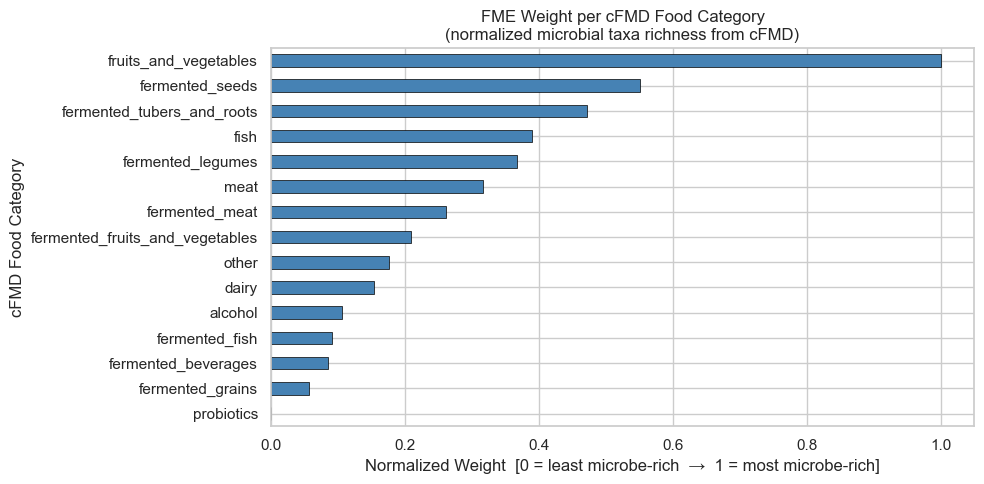

In [60]:
# ── Visualize FME weights ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
cfmd_category_weight_normalized.sort_values().plot(
    kind="barh", color="steelblue", edgecolor="black", linewidth=0.5
)
plt.title("FME Weight per cFMD Food Category\n(normalized microbial taxa richness from cFMD)")
plt.xlabel("Normalized Weight  [0 = least microbe-rich  →  1 = most microbe-rich]")
plt.ylabel("cFMD Food Category")
plt.tight_layout()
plt.show()


---
## Section 5 – Data Mapping: Diet Items → cFMD Food Categories

**Goal:** Map each food item in the Johnson et al. dietary records to a cFMD food category,
creating a unified representation of food-derived microbial exposure.

**Method:** Extract the L1 (top-level) taxonomy label from the `taxonomy` column of `diet_raw`
(e.g. `L1_Milk_and_Milk_Products` → `dairy`) and map it to the matching cFMD category.


In [61]:
# ── Extract L1 food category from taxonomy string ───────────────────────────────
def extract_l1_food_category(taxonomy_string):
    """
    Extract the top-level food category (L1) from the hierarchical taxonomy string.
    Example: 'L1_Milk_and_Milk_Products;L2_...' → 'milk and milk products'
    """
    if pd.isna(taxonomy_string):
        return "unknown"
    l1_segment = str(taxonomy_string).split(";")[0]
    return l1_segment.replace("L1_", "").replace("_", " ").strip().lower()

dietary_consumption_matrix["diet_l1_category"] = (
    dietary_consumption_matrix["taxonomy"]
    .apply(extract_l1_food_category)
)

print("Unique L1 diet categories found:")
for cat, count in dietary_consumption_matrix["diet_l1_category"].value_counts().items():
    print(f"  {cat:<45} {count:>5} food items")


Unique L1 diet categories found:
  grain product                                   407 food items
  vegetables                                      315 food items
  meat poultry fish and mixtures                  240 food items
  sugars sweets and beverages                     153 food items
  milk and milk products                          112 food items
  dry beans peas other legumes nuts and seeds      84 food items
  fruits                                           74 food items
  fats oils and salad dressings                    36 food items
  eggs                                             31 food items


In [62]:
# ── Mapping table: diet L1 category → cFMD category ────────────────────────────
DIET_L1_TO_CFMD_CATEGORY = {
    # Dairy
    "milk and milk products"            : "dairy",
    "dairy"                             : "dairy",
    "cheese"                            : "dairy",
    "yogurt"                            : "dairy",
    # Meat
    "meat poultry and game"             : "meat",
    "meat"                              : "meat",
    "poultry"                           : "meat",
    # Fish
    "fish and shellfish"                : "fish",
    "fish"                              : "fish",
    "seafood"                           : "fish",
    # Fruits and vegetables
    "vegetables and vegetable products" : "fruits_and_vegetables",
    "fruit"                             : "fruits_and_vegetables",
    "fruits"                            : "fruits_and_vegetables",
    "vegetables"                        : "fruits_and_vegetables",
    # Fermented grains
    "grain products"                    : "fermented_grains",
    "grains"                            : "fermented_grains",
    "bread"                             : "fermented_grains",
    "cereals and cereal products"       : "fermented_grains",
    # Alcohol / fermented beverages
    "alcoholic beverages"               : "alcohol",
    "alcohol"                           : "alcohol",
    "beverages"                         : "fermented_beverages",
    "nonalcoholic beverages"            : "fermented_beverages",
    # Legumes
    "legumes and legume products"       : "fermented_legumes",
    "legumes"                           : "fermented_legumes",
    "beans"                             : "fermented_legumes",
    # Seeds / nuts
    "nuts and seeds"                    : "fermented_seeds",
    "seeds"                             : "fermented_seeds",
    # Other / unmappable
    "fats and oils"                     : "other",
    "sugars and sweets"                 : "other",
    "soups sauces and gravies"          : "other",
    "mixed dishes"                      : "other",
    "snacks"                            : "other",
    "eggs"                              : "other",
    "spices and herbs"                  : "other",
    "unknown"                           : "unmapped",
}

dietary_consumption_matrix["cfmd_category"] = (
    dietary_consumption_matrix["diet_l1_category"]
    .map(DIET_L1_TO_CFMD_CATEGORY)
    .fillna("unmapped")
)

n_mapped   = (dietary_consumption_matrix["cfmd_category"] != "unmapped").sum()
n_unmapped = (dietary_consumption_matrix["cfmd_category"] == "unmapped").sum()
print(f"Food items mapped to a cFMD category : {n_mapped} / {len(dietary_consumption_matrix)}")
print(f"Food items unmapped                  : {n_unmapped}")


Food items mapped to a cFMD category : 532 / 1452
Food items unmapped                  : 920


In [63]:
# ── Attach FME weight to each food item ─────────────────────────────────────────
dietary_consumption_matrix["fme_weight"] = (
    dietary_consumption_matrix["cfmd_category"]
    .map(cfmd_category_weight_normalized.to_dict())
    .fillna(0.0)   # unmapped items get weight = 0
)

mapping_summary = (
    dietary_consumption_matrix
    .groupby(["diet_l1_category", "cfmd_category", "fme_weight"])
    .size()
    .reset_index(name="n_food_items")
    .sort_values("n_food_items", ascending=False)
)
print("Mapping summary (diet L1 → cFMD category → weight):")
display(mapping_summary)


Mapping summary (diet L1 → cFMD category → weight):


,diet_l1_category,cfmd_category,fme_weight,n_food_items
4,grain product,unmapped,0.0000,407
8,vegetables,fruits_and_vegetables,1.0000,315
5,meat poultry fish and mixtures,unmapped,0.0000,240
7,sugars sweets and beverages,unmapped,0.0000,153
6,milk and milk products,dairy,0.1541,112
0,dry beans peas other legumes nuts and seeds,unmapped,0.0000,84
3,fruits,fruits_and_vegetables,1.0000,74
2,fats oils and salad dressings,unmapped,0.0000,36
1,eggs,other,0.1762,31


---
## Section 6 – FME Score Calculation

**Formula:**
$$\text{FME}_{sample} = \sum_{\text{food items}} \text{consumption}_{\text{food, sample}} \times w_{\text{cfmd\_category(food)}}$$

Where:
- $\text{consumption}_{\text{food, sample}}$ = amount consumed (from `diet_raw`, grams or servings)
- $w$ = normalized cFMD microbial richness weight for the food's category

**Important:** Each `sample` corresponds to **one dietary day for one participant**.
The result is a score per fecal sample — not per participant.
Participant-level scores are derived later by averaging across their samples.


In [64]:
# ── Subset diet matrix to analytical samples only ───────────────────────────────
diet_abundance_matrix = (
    dietary_consumption_matrix[analytical_sample_ids]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

fme_weight_vector = dietary_consumption_matrix["fme_weight"].values  # shape: (n_food_items,)

# ── Compute FME score: weighted sum of food consumption per sample ───────────────
# Result: one FME score per fecal sample (= one dietary day per participant)
fme_score_per_sample = (
    diet_abundance_matrix
    .multiply(fme_weight_vector, axis=0)
    .sum(axis=0)
    .rename("fme_score_daily")
)
fme_score_per_sample.index.name = "fecal_sample_id"

print(f"FME scores computed for : {len(fme_score_per_sample)} fecal samples")
print(f"Score range             : {fme_score_per_sample.min():.4f} – {fme_score_per_sample.max():.4f}")
print(f"Score mean ± std        : {fme_score_per_sample.mean():.4f} ± {fme_score_per_sample.std():.4f}")
print(f"Non-zero scores         : {(fme_score_per_sample > 0).sum()}")
print()
display(fme_score_per_sample.reset_index().head(8))


FME scores computed for : 475 fecal samples
Score range             : 0.0000 – 331.2240
Score mean ± std        : 73.3252 ± 58.3071
Non-zero scores         : 437



,fecal_sample_id,fme_score_daily
0,MCT.f.0002,67.1961
1,MCT.f.0003,81.2412
2,MCT.f.0004,126.7711
3,MCT.f.0005,31.4846
4,MCT.f.0006,61.2266
5,MCT.f.0007,62.0231
6,MCT.f.0008,70.9874
7,MCT.f.0009,54.0086


In [65]:
# ── Participant-level FME summary (aggregate across samples) ────────────────────
# Note: samples are NOT independent — they come from the same 34 participants.
# Participant-level values are used ONLY for descriptive summaries,
# NOT as independent data points in statistical models.

fme_with_participant = pd.DataFrame({
    "fecal_sample_id" : fme_score_per_sample.index,
    "fme_score_daily" : fme_score_per_sample.values,
})
fme_with_participant["participant_id"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "UserName"]
    .values
)
fme_with_participant["study_day"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "StudyDayNo"]
    .values
)

# Participant-level summary (descriptive only)
participant_fme_summary = (
    fme_with_participant
    .groupby("participant_id")["fme_score_daily"]
    .agg(
        fme_mean     = "mean",
        fme_std      = "std",
        fme_min      = "min",
        fme_max      = "max",
        n_diet_days  = "count"
    )
    .reset_index()
)

print("Participant-level FME summary (descriptive — 34 participants):")
display(participant_fme_summary.sort_values("fme_mean", ascending=False).head(10))


Participant-level FME summary (descriptive — 34 participants):


,participant_id,fme_mean,fme_std,fme_min,fme_max,n_diet_days
1,MCTs03,147.8899,45.7548,68.0651,243.3253,12
5,MCTs07,143.4859,48.3133,86.0332,243.8429,16
2,MCTs04,143.1190,81.0506,36.6199,331.2240,15
6,MCTs08,140.2178,33.6074,84.4009,220.3516,17
14,MCTs16,130.9598,45.2371,69.7540,221.0863,14
27,MCTs31,128.7335,37.7598,83.9027,208.7920,15
23,MCTs26,122.0334,71.3654,24.5678,315.7055,17
16,MCTs19,99.4541,40.7179,14.6490,166.4480,15
17,MCTs20,88.6724,51.9185,24.4219,178.8966,12
24,MCTs27,85.2074,47.0410,5.0752,165.2448,14


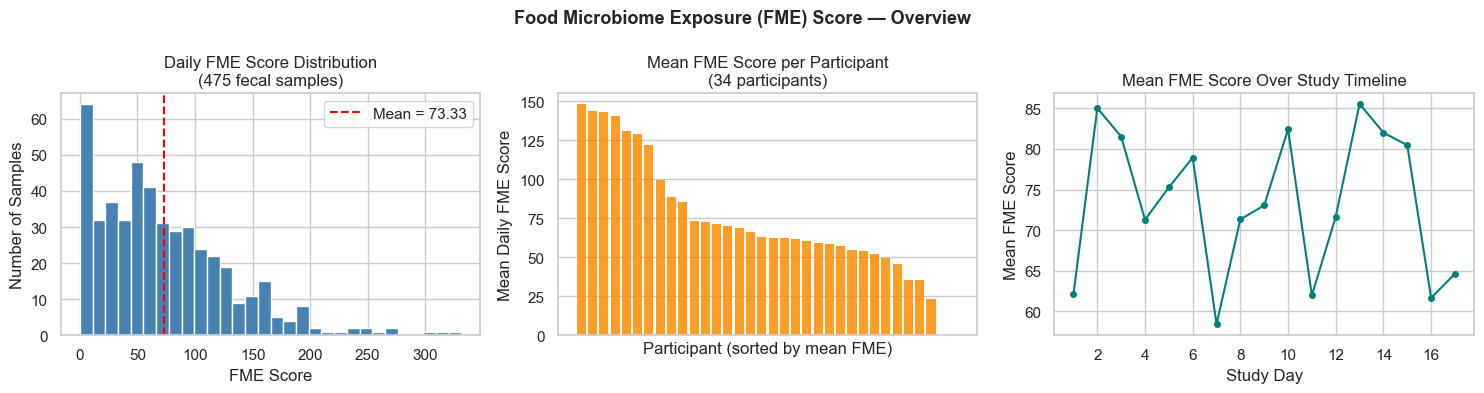

In [66]:
# ── Visualize FME scores ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of daily FME scores across all fecal samples
axes[0].hist(fme_score_per_sample.values, bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(fme_score_per_sample.mean(), color="red", linestyle="--",
                label=f"Mean = {fme_score_per_sample.mean():.2f}")
axes[0].set_title("Daily FME Score Distribution\n(475 fecal samples)")
axes[0].set_xlabel("FME Score")
axes[0].set_ylabel("Number of Samples")
axes[0].legend()

# Mean FME per participant (sorted)
sorted_participants = participant_fme_summary.sort_values("fme_mean", ascending=False)
axes[1].bar(range(len(sorted_participants)), sorted_participants["fme_mean"],
            color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_title(f"Mean FME Score per Participant\n({len(sorted_participants)} participants)")
axes[1].set_xlabel("Participant (sorted by mean FME)")
axes[1].set_ylabel("Mean Daily FME Score")
axes[1].set_xticks([])

# FME over study timeline (mean per study day)
fme_by_day = fme_with_participant.groupby("study_day")["fme_score_daily"].mean()
axes[2].plot(fme_by_day.index, fme_by_day.values,
             marker="o", color="teal", linewidth=1.5, markersize=4)
axes[2].set_title("Mean FME Score Over Study Timeline")
axes[2].set_xlabel("Study Day")
axes[2].set_ylabel("Mean FME Score")

plt.suptitle("Food Microbiome Exposure (FME) Score — Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 7 – Gut Microbiome Alpha Diversity per Fecal Sample

Compute **Shannon entropy** for each fecal sample as a measure of gut microbial richness and evenness.
This is the primary outcome variable (composition proxy) at the sample level.


In [67]:
# ── Shannon entropy per fecal sample ────────────────────────────────────────────
def compute_shannon_entropy(abundance_column):
    """Shannon entropy H = -Σ p_i * log(p_i) for non-zero taxa."""
    positive_values = abundance_column[abundance_column > 0]
    if positive_values.sum() == 0:
        return np.nan
    proportions = positive_values / positive_values.sum()
    return float(-np.sum(proportions * np.log(proportions)))

gut_microbiome_analytical = gut_microbiome_abundance[analytical_sample_ids]
shannon_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_shannon_entropy, axis=0)
    .rename("shannon_diversity")
)
shannon_diversity_per_sample.index.name = "fecal_sample_id"

print(f"Shannon diversity computed for : {shannon_diversity_per_sample.notna().sum()} samples")
print(f"Range  : {shannon_diversity_per_sample.min():.3f} – {shannon_diversity_per_sample.max():.3f}")
print(f"Mean   : {shannon_diversity_per_sample.mean():.3f}")


Shannon diversity computed for : 475 samples
Range  : 1.572 – 3.731
Mean   : 2.865


---
## Section 8 – Gut Microbiome Stability per Participant

**Stability** = how consistent is a participant's gut microbiome across their sampling days?

We use the **coefficient of variation (CV)** of Shannon diversity across a participant's samples:
$$CV_{participant} = \frac{\sigma(\text{Shannon})}{\mu(\text{Shannon})}$$

Lower CV = more stable microbiome.

> This is computed at the **participant level** (34 values) and joined back to the sample-level table as a per-participant attribute.


In [68]:
# ── Map each fecal sample to its participant ─────────────────────────────────────
sample_to_participant = (
    fecal_sample_metadata
    .loc[analytical_sample_ids, "UserName"]
    .rename("participant_id")
)

shannon_with_participant = pd.DataFrame({
    "fecal_sample_id" : shannon_diversity_per_sample.index,
    "shannon_diversity": shannon_diversity_per_sample.values,
}).set_index("fecal_sample_id")
shannon_with_participant["participant_id"] = sample_to_participant

# ── Participant-level stability (CV of Shannon across their samples) ───────────
participant_gut_stability = (
    shannon_with_participant
    .groupby("participant_id")["shannon_diversity"]
    .agg(
        participant_shannon_mean = "mean",
        participant_shannon_std  = "std",
        participant_n_samples    = "count"
    )
    .assign(
        participant_shannon_cv = lambda df:
            df["participant_shannon_std"] / df["participant_shannon_mean"]
    )
    .reset_index()
)

print(f"Gut stability computed for {len(participant_gut_stability)} participants")
print(f"Shannon CV range : {participant_gut_stability['participant_shannon_cv'].min():.4f} – "
      f"{participant_gut_stability['participant_shannon_cv'].max():.4f}")
display(participant_gut_stability.sort_values("participant_shannon_cv").head(8))


Gut stability computed for 34 participants
Shannon CV range : 0.0202 – 0.1799


,participant_id,participant_shannon_mean,participant_shannon_std,participant_n_samples,participant_shannon_cv
5,MCTs07,3.0731,0.0621,16,0.0202
17,MCTs20,3.2696,0.0736,12,0.0225
29,MCTs33,3.0863,0.0876,17,0.0284
11,MCTs13,3.1848,0.0942,11,0.0296
19,MCTs22,2.9985,0.0912,15,0.0304
7,MCTs09,3.0362,0.0948,16,0.0312
30,MCTs34,2.9806,0.1022,12,0.0343
8,MCTs10,3.0279,0.1045,14,0.0345


---
## Section 9 – Assemble the Statistical Analysis Dataset

Merge all variables into one clean table at the **fecal sample level**.
Each row = one fecal sample = one dietary day for one participant.

| Column group | Columns | Role in statistical model |
|---|---|---|
| Identity | `fecal_sample_id`, `participant_id`, `study_day` | Grouping / random effect |
| Demographics | `Age`, `BMI`, `Gender` | Fixed-effect covariates |
| **FME score** | `fme_score_daily` | **Main predictor** |
| **Gut diversity** | `shannon_diversity` | **Main outcome** |
| **Gut stability** | `participant_shannon_cv` | **Secondary outcome** |
| Nutrition | `KCAL`, `FIBE`, `PROT`, `TFAT`, `CARB` | Dietary confounders |


In [69]:
# ── Step 1: Base table — fecal sample IDs ──────────────────────────────────────
statistical_analysis_dataset = pd.DataFrame(
    index=pd.Index(analytical_sample_ids, name="fecal_sample_id")
)

# ── Step 2: Participant identity and demographics ───────────────────────────────
participant_meta_cols = ["UserName", "StudyDayNo", "Gender", "Age", "BMI",
                         "Weight", "Supplement", "Medications"]
participant_meta_cols = [c for c in participant_meta_cols
                         if c in fecal_sample_metadata.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    fecal_sample_metadata[participant_meta_cols]
    .rename(columns={"UserName": "participant_id", "StudyDayNo": "study_day"}),
    how="left"
)

# ── Step 3: Daily FME score ─────────────────────────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    fme_score_per_sample.rename("fme_score_daily"),
    how="left"
)

# ── Step 4: Gut alpha diversity (Shannon) ──────────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    shannon_diversity_per_sample.rename("shannon_diversity"),
    how="left"
)

# ── Step 5: Participant-level gut stability (CV) ────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    participant_gut_stability.set_index("participant_id")[
        ["participant_shannon_cv", "participant_shannon_mean", "participant_n_samples"]
    ],
    on="participant_id",
    how="left"
)

# ── Step 6: Daily nutrition totals ─────────────────────────────────────────────
nutrition_cols_keep = ["KCAL", "PROT", "TFAT", "CARB", "FIBE",
                       "SUGR", "SODI", "D_TOTAL", "D_YOGURT", "D_CHEESE",
                       "PF_MEAT", "PF_SEAFD_HI", "G_WHOLE"]
nutrition_cols_keep = [c for c in nutrition_cols_keep
                       if c in daily_nutrition_totals.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    daily_nutrition_totals[nutrition_cols_keep],
    how="left"
)

print(f"Statistical dataset shape  : {statistical_analysis_dataset.shape}")
print(f"Fecal samples (rows)       : {statistical_analysis_dataset.shape[0]}")
print(f"Variables (columns)        : {statistical_analysis_dataset.shape[1]}")
print(f"Participants represented   : {statistical_analysis_dataset['participant_id'].nunique()}")
print(f"Complete rows (no NaN)     : {statistical_analysis_dataset.dropna().shape[0]}")


Statistical dataset shape  : (475, 26)
Fecal samples (rows)       : 475
Variables (columns)        : 26
Participants represented   : 34
Complete rows (no NaN)     : 220


In [70]:
# ── Missing value report ───────────────────────────────────────────────────────
missing_report = (
    statistical_analysis_dataset.isnull().sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_missing"})
)
missing_report["pct_missing"] = (
    missing_report["n_missing"] / len(statistical_analysis_dataset) * 100
).round(1)
missing_report = missing_report[missing_report["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_report.empty:
    print("No missing values in the statistical dataset.")
else:
    print("Missing values:")
    display(missing_report)


Missing values:


,variable,n_missing,pct_missing
7,Medications,255,53.7000


In [71]:
# ── Descriptive statistics ─────────────────────────────────────────────────────
key_vars = ["fme_score_daily", "shannon_diversity",
            "participant_shannon_cv", "Age", "BMI", "KCAL", "FIBE"]
key_vars = [v for v in key_vars if v in statistical_analysis_dataset.columns]

print("Descriptive statistics — key variables:")
display(statistical_analysis_dataset[key_vars].describe().T.round(3))


Descriptive statistics — key variables:


,count,mean,std,min,25%,50%,75%,max
fme_score_daily,475.0000,73.3250,58.3070,0.0000,29.3220,61.7780,104.2700,331.2240
shannon_diversity,475.0000,2.8650,0.4130,1.5720,2.6110,2.9640,3.1430,3.7310
participant_shannon_cv,475.0000,0.0630,0.0380,0.0200,0.0360,0.0490,0.0800,0.1800
Age,475.0000,31.1520,10.1560,19.7000,23.9000,28.5000,37.0000,61.6000
BMI,475.0000,23.1750,3.2920,17.0000,21.1000,22.9000,25.9000,31.6000
KCAL,475.0000,2110.5630,735.4510,722.5520,1599.1800,2028.1680,2494.0980,5085.9770
FIBE,475.0000,22.3370,11.6000,3.6180,14.8500,19.6940,26.7120,67.5020


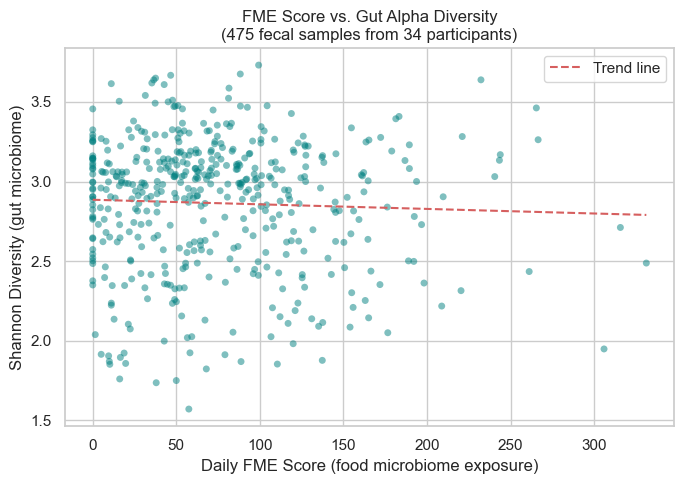

In [72]:
# ── Quick scatter: FME score vs. gut Shannon diversity ─────────────────────────
plot_df = statistical_analysis_dataset.dropna(
    subset=["fme_score_daily", "shannon_diversity"]
)

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["fme_score_daily"], plot_df["shannon_diversity"],
            alpha=0.5, s=25, c="teal", edgecolors="none")
if len(plot_df) > 2:
    z = np.polyfit(plot_df["fme_score_daily"], plot_df["shannon_diversity"], 1)
    x_line = np.linspace(plot_df["fme_score_daily"].min(),
                         plot_df["fme_score_daily"].max(), 100)
    plt.plot(x_line, np.poly1d(z)(x_line), "r--", lw=1.5, label="Trend line")
plt.xlabel("Daily FME Score (food microbiome exposure)")
plt.ylabel("Shannon Diversity (gut microbiome)")
plt.title("FME Score vs. Gut Alpha Diversity\n(475 fecal samples from 34 participants)")
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 10 – Save Outputs

In [73]:
# ── Save statistical analysis dataset ─────────────────────────────────────────
statistical_analysis_dataset.to_csv(DATA_DIR / "fme_statistical_dataset.csv")
participant_gut_stability.to_csv(DATA_DIR / "participant_gut_stability.csv", index=False)
fme_with_participant.to_csv(DATA_DIR / "fme_sample_level_scores.csv", index=False)

print("Saved:")
print(f"  fme_statistical_dataset.csv    {statistical_analysis_dataset.shape}  — main analytical table")
print(f"  participant_gut_stability.csv  {participant_gut_stability.shape}  — stability per participant")
print(f"  fme_sample_level_scores.csv    {fme_with_participant.shape}  — FME scores with participant labels")


Saved:
  fme_statistical_dataset.csv    (475, 26)  — main analytical table
  participant_gut_stability.csv  (34, 5)  — stability per participant
  fme_sample_level_scores.csv    (475, 4)  — FME scores with participant labels


---
## Summary

### What was built
The `fme_statistical_dataset.csv` table is the **primary input for all statistical analyses**.

### Structural note (important for modelling)
- **Unit of observation**: fecal sample (475 rows)
- **Grouping variable**: `participant_id` (34 participants) → must be included as a **random effect**
- **Main predictor**: `fme_score_daily`
- **Main outcomes**: `shannon_diversity` (composition), `participant_shannon_cv` (stability)

### Recommended next steps
```
Mixed-effects model (composition):
  shannon_diversity ~ fme_score_daily + Age + BMI + KCAL + (1 | participant_id)

Mixed-effects model (stability — participant level, n=34):
  participant_shannon_cv ~ mean(fme_score_daily) + Age + BMI
```


Model test part

In [74]:
#Load data
df_fme = pd.read_csv(DATA_DIR / "fme_statistical_dataset.csv", index_col=0)
print(f"Loaded dataset: {df_fme.shape[0]} samples, {df_fme.shape[1]} columns")
print(f"Participants: {df_fme['participant_id'].nunique()}")

print("=== Sample of  Data ===")
print(df_fme.head())

Loaded dataset: 475 samples, 26 columns
Participants: 34
=== Sample of  Data ===
                participant_id  study_day Gender     Age     BMI  Weight  \
fecal_sample_id                                                            
MCT.f.0002              MCTs01          2      F 25.9000 25.0000 74.6000   
MCT.f.0003              MCTs01          3      F 25.9000 25.0000 74.6000   
MCT.f.0004              MCTs01          4      F 25.9000 25.0000 74.6000   
MCT.f.0005              MCTs01          5      F 25.9000 25.0000 74.6000   
MCT.f.0006              MCTs01          6      F 25.9000 25.0000 74.6000   

                Supplement             Medications  fme_score_daily  \
fecal_sample_id                                                       
MCT.f.0002            EVOO  Nexplanon (bc implant)          67.1961   
MCT.f.0003            EVOO  Nexplanon (bc implant)          81.2412   
MCT.f.0004            EVOO  Nexplanon (bc implant)         126.7711   
MCT.f.0005            EVOO  Nex

In [75]:
#Turn shannon diversity from contiues to binary
median_shannon = df_fme["shannon_diversity"].median()
df_fme["High_Diversity_Class"] = (df_fme["shannon_diversity"] > median_shannon).astype(int)
print(f"\nTarget distribution (High=1 / Low=0):")
print(df_fme["High_Diversity_Class"].value_counts())


Target distribution (High=1 / Low=0):
High_Diversity_Class
0    238
1    237
Name: count, dtype: int64


In [76]:
#Features
feature_cols = ["fme_score_daily", "KCAL", "FIBE", "CARB", "TFAT", "Age", "BMI"]
feature_cols = [f for f in feature_cols if f in df_fme.columns]

In [77]:
#Drop rows with missing values in features or target
df_fme_clean = df_fme[feature_cols + ["High_Diversity_Class", "participant_id"]].dropna()

#Prepare data for modeling
X = df_fme_clean[feature_cols]
print(X.columns.tolist())
y = df_fme_clean['High_Diversity_Class']
groups = df_fme_clean['participant_id']

['fme_score_daily', 'KCAL', 'FIBE', 'CARB', 'TFAT', 'Age', 'BMI']


In [78]:
#Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

#Cross validation
gkf = GroupKFold(n_splits=5)

#Train and evaluate models
print("\n=== Model Comparison Results ===")
best_model_name = ""
best_auc = 0
best_model_feat_obj = None


=== Model Comparison Results ===


In [79]:
for name, model in models.items():
    acc_scores = []
    auc_scores = []
    
    #Make sure subjects are not split between train and test sets
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        #Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        #Train
        model.fit(X_train_scaled, y_train)
        
        #Predictions
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        #Calculate metrics
        acc_scores.append(accuracy_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_proba))
    
    #Compute mean metrics across folds
    mean_acc = np.mean(acc_scores)
    mean_auc = np.mean(auc_scores)
    
    print(f"\n[{name}]")
    print(f"Mean Accuracy: {mean_acc:.3f}")
    print(f"Mean ROC-AUC:  {mean_auc:.3f}")
    
    #Save best model based on AUC
    if mean_auc > best_auc:
        best_auc       = mean_auc
        best_model_name = name
        best_model_obj  = model

print(f"\n Best Model: {best_model_name} (Mean AUC = {best_auc:.3f})")


[Logistic Regression]
Mean Accuracy: 0.442
Mean ROC-AUC:  0.452

[Random Forest]
Mean Accuracy: 0.516
Mean ROC-AUC:  0.526

[XGBoost]
Mean Accuracy: 0.533
Mean ROC-AUC:  0.561

 Best Model: XGBoost (Mean AUC = 0.561)


In [80]:
#Feature importance for best model
if best_model_name == "Logistic Regression":
    importances = np.abs(best_model_obj.coef_[0])
    title       = "Feature Importance (Logistic Regression — Absolute Coefficients)"
    xlabel      = "Absolute Coefficient Value"
else:
    importances = best_model_obj.feature_importances_
    title       = f"Feature Importance ({best_model_name})"
    xlabel      = "Importance Score"
 
indices      = np.argsort(importances)[::-1]
feature_arr  = np.array(feature_cols)
 

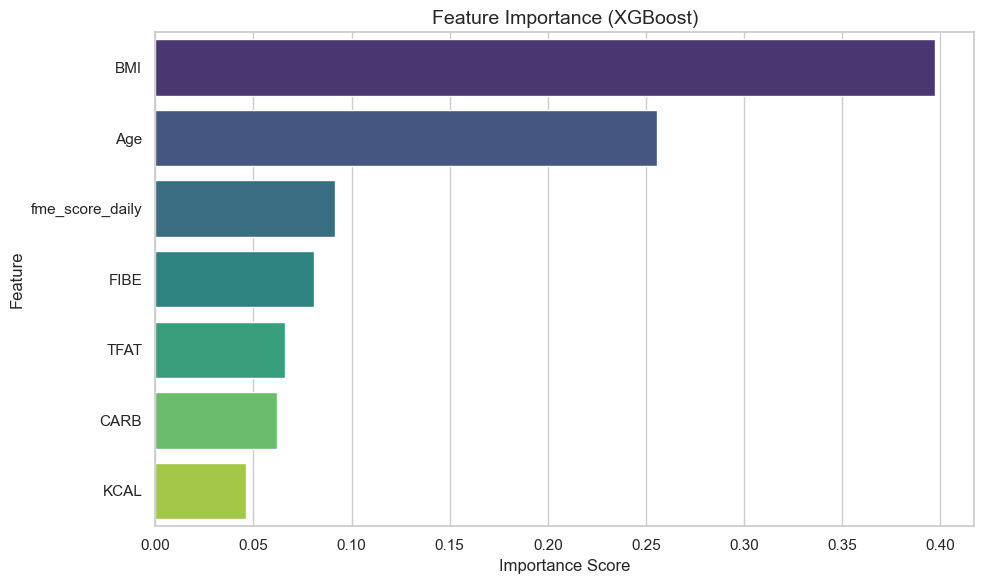

Plot saved: c:\Users\mayag\PythonForuni\ProjectYear3\data\feature_importance.png


In [81]:
#Plot feature importance

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_arr[indices], hue=feature_arr[indices], palette="viridis", legend=False)
plt.title(title, fontsize=14)
plt.xlabel(xlabel, fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "feature_importance.png", dpi=150)      #Save before showings
plt.show()
print(f"Plot saved: {DATA_DIR / 'feature_importance.png'}")